In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

import glob

from natsort import natsorted

# # import lsqfit
# from lib import Jackknife
# from lib import simple_mean
# from lib import format_print

# plt.rcParams['figure.dpi'] = 300

In [2]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins -1

    def mean( self ):
        return self.est

    def var( self ):
        return self.var_est

    def err( self ):
        return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    return np.mean(resmpld, axis=0)

def jack_avg(i, binsize, np_data):
    return np_data[i]

def take_abs(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    mean = np.mean(resmpld, axis=0)
    # mean = mean[1:int(Nt/2)] + np.flip( mean[int(Nt/2):Nt-1], axis=0 )

    return np.sqrt(mean.T[1]**2 + mean.T[2]**2)


def take_real(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    mean = np.mean(resmpld, axis=0)
    # mean = mean[1:int(Nt/2)] + np.flip( mean[int(Nt/2):Nt-1], axis=0 )
    return mean.T[1]


def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'+': '+'{num:.{width}f}'.format(num=(exact-cen)/err, width=i+1)+' sigma'

In [3]:
pwd

'/mnt/barracuda22/qed3/qed3/src/both_3d'

In [4]:
# dir1='/projectnb/qfe/nmatsum/qed3/src/both_3d/'
# dir1='/media/nobu/baracuda_14/qed3/qed3/src/both_3d/'
dir1='/mnt/barracuda22/qed3/qed3/src/both_3d/'

In [5]:
results=[]

In [6]:
dir1+"data_free_vmRe0.000000vmIm0.000000/corr_deter_exact_L1"

'/mnt/barracuda22/qed3/qed3/src/both_3d/data_free_vmRe0.000000vmIm0.000000/corr_deter_exact_L1'

In [7]:
# Nf=2

# # gsq="8.000000"
# gsq="4.000000"
# # gsq="1.000000"
# # gsq="0.500000"
# # gsq="0.100000"

# # nu0="0.800000"
# # nu0="2.000000"
# nu0="2.000000"

# nu1="3.000000" # nu0 # "1.000000"
# # nu1="2.000000"
# # nu1="1.000000"

# at="0.200000"
# Nt=96
# L=1

# CFT current-correlator check: Eqs. (4.28) and (4.31)  [qed3int_v2-11]

Test of `jj_local_deter_claude.cu` (local / ultralocal current) fed the **analytic
continuum propagator**:

    ./a.out --prop-file cont_prop_L1/Dinv.0.h5 --out-tag cont      # free, L=1

which writes `data_free_vmRe0.000000vmIm0.000000/corr_deter_local_cont_L1/corr.0.h5`.

Same-site temporal/spatial projections, conserved-current dimension $\Delta=D-1=2$ in $D=3$:

$$G_t(t) = -C_J\, e^{-\Delta t}\,(1-e^{-t})^{-2\Delta},\qquad
  G_s(t) =  C_J\,(D-1)\, e^{-\Delta t}\,(1-e^{-t})^{-2\Delta},$$

so the convention-free prediction is the ratio $G_s/G_t=-(D-1)=-2$.
The local current is a **site object**: each HDF5 key `s1`,`s2`,`s3` is a diagonal Pauli
channel $\langle\sigma^a\sigma^a\rangle$ at the same site.  $G_t=$ `s3` (Eq. 4.31, temporal);
$G_s=$ `s1`$+$`s2` (Eq. 4.28, spatial).  Time axis = $L=1$ lattice points $t=a_t\,n_t$,
$a_t=0.2$.  The overall constant $C_J$ is not predicted (and the lattice sum carries an
overall area factor), so the magnitude check is shape-only; the ratio is the sharp test.

In [8]:
import h5py

at_cft = 0.2
Nt_cft = 128
L_cft  = 1

# dir1 is set near the top of the notebook (the both_3d/ path)
ESN_cft = dir1 + "data_free_vmRe0.000000vmIm0.000000/"

def load_Vpp(corrdir, proj, origin="t0_0", k=0):
    # jj_local_deter_claude.cu output: h0/<origin>/<proj>/Vpp ; proj = "s1","s2","s3".
    # Each is a diagonal Pauli channel <sigma_a sigma_a> (site object).  G_t = s3 (Eq.4.31),
    # G_s = s1 + s2 (Eq.4.28).  disc (one-point) ~0 here, so Vpp is the connected correlator.
    path = ESN_cft + corrdir + "/corr." + str(k) + ".h5"
    with h5py.File(path, "r") as f:
        key = "h0/" + origin + "/" + proj + "/Vpp"
        return f[key+"/real"][()] + 1j*f[key+"/imag"][()]

In [9]:
# qed3int_v2-11  Eqs. (4.28)/(4.31), same-site, Delta = D - 1 = 2
Delta_cft = 2.0

def cft_shape(t):
    return np.exp(-Delta_cft*t) * (1.0 - np.exp(-t))**(-2.0*Delta_cft)

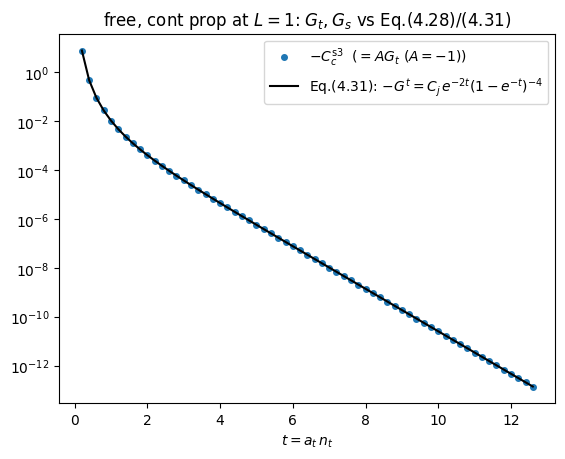

In [10]:
# G_t = s3, G_s = s1+s2 vs the Eq.(4.28)/(4.31) shape (magnitude, log scale)
corrdir = "corr_deter_local_cont_L1"

gt = load_Vpp(corrdir, "s3").real
gs = (load_Vpp(corrdir, "s1") + load_Vpp(corrdir, "s2")).real

dt = np.arange(1, int(Nt_cft/2))
t  = dt * at_cft

# fix the undetermined overall scale of the CFT curve by matching |G_t| at one separation
ref = 5
Cj = -gt[ref] / cft_shape(t[ref-1])

plt.figure()
plt.plot(t, -gt[dt], 'o', ms=4, label="$-C_c^{\\rm s3}$  ($ = A G_t$ ($A=-1$))")
# plt.plot(t, np.abs(gs[dt]), 's', ms=4, label="lattice $G_s$ (s1+s2)")
plt.plot(t, Cj*cft_shape(t), 'k-',
         label=r"Eq.(4.31): $-G^t = C_j \, e^{-2t}(1-e^{-t})^{-4}$")
plt.yscale("log")
plt.xlabel(r"$t = a_t\, n_t$")
plt.title("free, cont prop at $L=1$: $G_t,G_s$ vs Eq.(4.28)/(4.31)")
plt.legend()
plt.savefig("cft_GtGs_cont_L1.pdf", bbox_inches="tight")

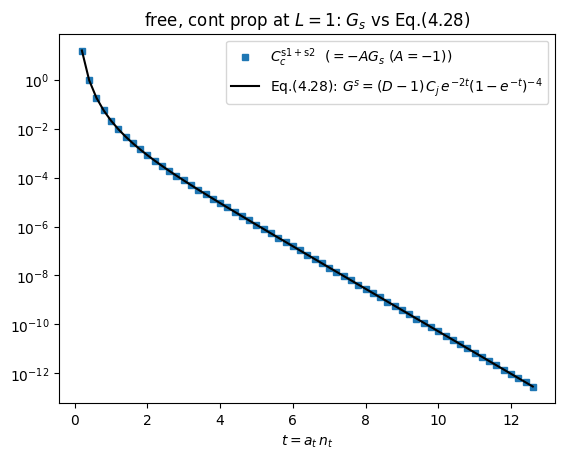

In [11]:
# sp counterpart: G_s = s1 + s2 vs Eq.(4.28) (magnitude, log scale).
# Eq.(4.28): G_s = +C_J (D-1) e^{-Delta t}(1-e^{-t})^{-2 Delta}, so Re G_s > 0 (opposite to G_t).
corrdir = "corr_deter_local_cont_L1"

gs = (load_Vpp(corrdir, "s1") + load_Vpp(corrdir, "s2")).real

dt = np.arange(1, int(Nt_cft/2))
t  = dt * at_cft

plt.figure()
plt.plot(t, gs[dt], 's', ms=4, label="$C_c^{\\rm s1+s2}$  ($ = -A G_s$ ($A=-1$))")
plt.plot(t, 2.0*Cj*cft_shape(t), 'k-',
         label=r"Eq.(4.28): $G^s = (D-1) \, C_j\,e^{-2t}(1-e^{-t})^{-4}$")
plt.yscale("log")
plt.xlabel(r"$t = a_t\, n_t$")
plt.title("free, cont prop at $L=1$: $G_s$ vs Eq.(4.28)")
plt.legend()
plt.savefig("cft_Gs_cont_L1.pdf", bbox_inches="tight")

In [12]:
gs[dt] / gt[dt]

array([-2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2.,
       -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2.,
       -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2.,
       -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2.,
       -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2.])

## Ylm tower — Eq. (4.35)  [qed3int_v2-11]

Spherical-harmonic descendants of the temporal current correlator $G_t$ (the `s3` channel). The
diagonal-$m$ Legendre coefficient (HDF5 key `ylm/l{0,1,2}`),

$$g_\ell(t)\equiv G^t_{\ell\ell}(t)=\frac{1}{2\ell+1}\sum_{m=-\ell}^{\ell}\big\langle j_{\ell m}(t_0)\,j_{\ell m}(t)\big\rangle,
\qquad j_{\ell m}(t)=\sum_n A_n\,Y_{\ell m}(\hat n)\,\sigma_3(n,t),$$

is the lattice quadrature of $\tfrac12\int_{-1}^{1}G_t(t;x)P_\ell(x)\,dx$ (same continuum propagator as
`jj_cft_ylm_check_claude.cc`, summed over the $L=1$ sites). Prediction (Eq. 4.35, $\Delta=2$,
$C_j=-1/(8\pi^2)$):

$$G^t_{11}(t)\to \tfrac{1}{24\pi^2}e^{-2t},\qquad G^t_{22}(t)\to \tfrac{1}{10\pi^2}e^{-3t},\qquad G^t_{00}\to 0.$$

Convention-free checks: decay rates $(2,3)$ for $\ell=(1,2)$; ratio $G^t_{22}e^{3t}/G^t_{11}e^{2t}\to 12/5=2.4$;
$G^t_{00}/G^t_{11}\to 0$.

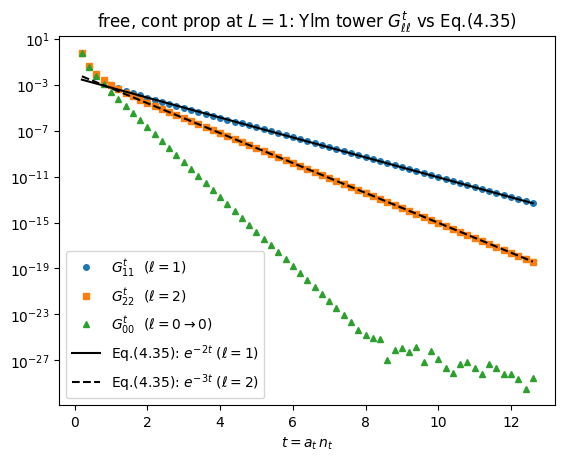

In [13]:
# Ylm tower g_l(t) (HDF5 key ylm/l{0,1,2}) vs Eq.(4.35) shapes (magnitude, log scale)
corrdir = "corr_deter_local_cont_L1"

g0 = load_Vpp(corrdir, "ylm/l0").real
g1 = load_Vpp(corrdir, "ylm/l1").real
g2 = load_Vpp(corrdir, "ylm/l2").real

dt = np.arange(1, int(Nt_cft/2))
t  = dt * at_cft

# CFT shapes, amplitude matched at one separation each (overall C_j undetermined)
ref = 5

plt.figure()
plt.plot(t, -g1[dt], 'o', ms=4, label=r"$G^t_{11}$  ($\ell=1$)")
plt.plot(t, -g2[dt], 's', ms=4, label=r"$G^t_{22}$  ($\ell=2$)")
plt.plot(t, np.abs(g0[dt]), '^', ms=4, label=r"$G^t_{00}$  ($\ell=0\to0$)")
plt.plot(t, (1.0/3.0)*Cj*np.exp(-2.0*t), 'k-',  label=r"Eq.(4.35): $e^{-2t}$ ($\ell=1$)")
plt.plot(t, (4.0/5.0)*Cj*np.exp(-3.0*t), 'k--', label=r"Eq.(4.35): $e^{-3t}$ ($\ell=2$)")
plt.yscale("log")
plt.xlabel(r"$t = a_t\, n_t$")
plt.title("free, cont prop at $L=1$: Ylm tower $G^t_{\\ell\\ell}$ vs Eq.(4.35)")
plt.legend()
plt.savefig("cft_ylm_cont_L1.pdf", bbox_inches="tight")

predicted rates: l=1 -> 2.0,  l=2 -> 3.0
l=1 rate (mid t): [2.001 2.001 2.001 2.    2.    2.    2.   ]
l=2 rate (mid t): [3.014 3.009 3.006 3.004 3.003 3.002 3.001]

predicted ratio g2 e^{3t}/g1 e^{2t} -> 12/5 = 2.4
ratio (mid t): [2.4597 2.4403 2.4271 2.4182 2.4123 2.4082 2.4055 2.4037]

g0/g1 -> 0 : [0.0001 0.0001 0.     0.     0.     0.     0.     0.    ]


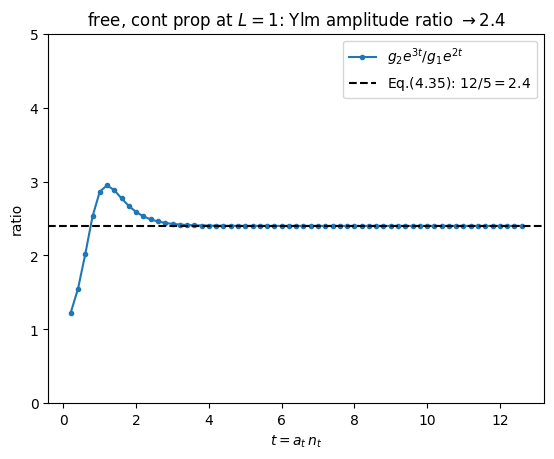

In [14]:
# Convention-free Eq.(4.35) checks: decay rates -> (2,3); ratio g2 e^{3t}/g1 e^{2t} -> 12/5 = 2.4; g0/g1 -> 0
dt = np.arange(1, int(Nt_cft/2))
t  = dt * at_cft

# effective decay rate  m_eff(t) = -(1/at) log( g[n+1]/g[n] )
def eff_rate(g):
    gg = g[dt]
    return -np.log(np.abs(gg[1:]/gg[:-1])) / at_cft

print("predicted rates: l=1 -> 2.0,  l=2 -> 3.0")
print("l=1 rate (mid t):", np.round(eff_rate(g1)[15:22], 3))
print("l=2 rate (mid t):", np.round(eff_rate(g2)[15:22], 3))

ratio = (g2[dt]*np.exp(3.0*t)) / (g1[dt]*np.exp(2.0*t))
print("\npredicted ratio g2 e^{3t}/g1 e^{2t} -> 12/5 = 2.4")
print("ratio (mid t):", np.round(ratio[12:20], 4))
print("\ng0/g1 -> 0 :", np.round((g0[dt]/g1[dt])[12:20], 4))

plt.figure()
plt.plot(t, ratio, '.-', label=r"$g_2 e^{3t}/g_1 e^{2t}$")
plt.axhline(12.0/5.0, color='k', ls='dashed', label=r"Eq.(4.35): $12/5 = 2.4$")
plt.xlabel(r"$t = a_t\, n_t$"); plt.ylabel("ratio"); plt.ylim(0, 5)
plt.title("free, cont prop at $L=1$: Ylm amplitude ratio $\\to 2.4$")
plt.legend()
plt.savefig("cft_ylm_ratio_L1.pdf", bbox_inches="tight")

## $L$-convergence: $L=1,2,4$  (cont prop)

The same deterministic local-current trace fed the continuum propagator
`cont_prop_L{1,2,4}/Dinv.0.h5` (output dirs `corr_deter_local_cont_L{1,2,4}`). Two regimes:

- **$G_t$ (s3), $G_s$ (s1+s2)** are *same-site* objects: the same-site block is the exact continuum
  $c_3(t)\sigma_3$ and $\sum_n A_n=4\pi$ at every $L$, so these are $L$-independent and collapse onto
  Eq.(4.31)/(4.28).
- **The Ylm tower** is an *off-site* sphere quadrature: the $L=1$ 12-site sum is coarse, and $L=2$
  (42 sites), $L=4$ (162 sites) refine it toward the Eq.(4.35) rates $(2,3)$ and ratio $12/5=2.4$.

(Requires running `tmp_claude.sh` for $L=2,4$ first; $L=4$ loads the 26 GB dense $P$, $\sim$41 GB RAM.)

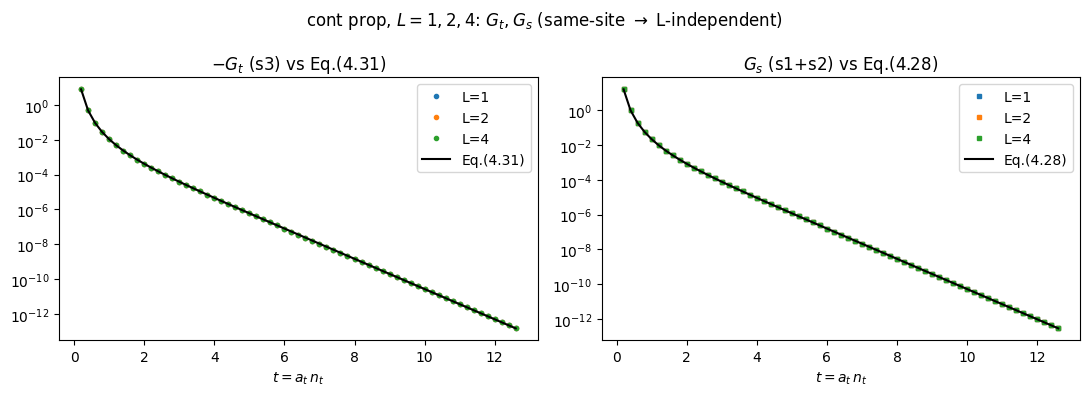

In [15]:
# G_t (s3) and G_s (s1+s2) overlay for L=1,2,4 vs Eq.(4.31)/(4.28).
# Same-site objects -> exact at every L (curves collapse; sum_n A_n = 4pi is L-independent).
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
ref = 5

# shared amplitude Cj from the first available L (G_t is L-independent)
CjL = None
for L in [1, 2, 4]:
    try:
        gtL = load_Vpp("corr_deter_local_cont_L%d" % L, "s3").real
        CjL = -gtL[ref] / cft_shape(t[ref-1]); break
    except (OSError, KeyError):
        pass

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for L in [1, 2, 4]:
    cd = "corr_deter_local_cont_L%d" % L
    try:
        gt = load_Vpp(cd, "s3").real
        gs = (load_Vpp(cd, "s1") + load_Vpp(cd, "s2")).real
    except (OSError, KeyError):
        print("missing:", cd); continue
    ax[0].plot(t, -gt[dt], 'o', ms=3, label="L=%d" % L)
    ax[1].plot(t,  gs[dt], 's', ms=3, label="L=%d" % L)
if CjL is not None:
    ax[0].plot(t,     Cj*cft_shape(t), 'k-', label="Eq.(4.31)")
    ax[1].plot(t, 2.0*Cj*cft_shape(t), 'k-', label="Eq.(4.28)")
for a, ti in zip(ax, [r"$-G_t$ (s3) vs Eq.(4.31)", r"$G_s$ (s1+s2) vs Eq.(4.28)"]):
    a.set_yscale("log"); a.set_xlabel(r"$t = a_t\, n_t$"); a.set_title(ti); a.legend()
fig.suptitle("cont prop, $L=1,2,4$: $G_t,G_s$ (same-site $\\to$ L-independent)")
fig.tight_layout()
fig.savefig("cft_GtGs_cont_L124.pdf", bbox_inches="tight")

In [16]:
!

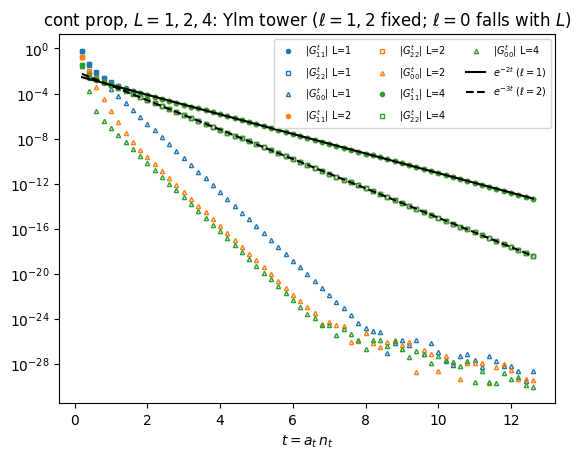

In [17]:
# Ylm tower |G^t_00|,|G^t_11|,|G^t_22| overlay for L=1,2,4 vs Eq.(4.35).
# NB: g0,g1,g2 are reloaded PER L (the l=0 mode must be read for each L to see it fall with L).
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
col = {1: 'C0', 2: 'C1', 4: 'C2'}

plt.figure()
for L in [1, 2, 4]:
    cd = "corr_deter_local_cont_L%d" % L
    try:
        g0 = load_Vpp(cd, "ylm/l0").real
        g1 = load_Vpp(cd, "ylm/l1").real
        g2 = load_Vpp(cd, "ylm/l2").real
    except (OSError, KeyError):
        print("missing:", cd); continue
    plt.plot(t, np.abs(g1[dt]), 'o', ms=3, color=col[L],             label=r"$|G^t_{11}|$ L=%d" % L)
    plt.plot(t, np.abs(g2[dt]), 's', ms=3, color=col[L], mfc='none', label=r"$|G^t_{22}|$ L=%d" % L)
    plt.plot(t, np.abs(g0[dt]), '^', ms=3, color=col[L], mfc='none', label=r"$|G^t_{00}|$ L=%d" % L)
# Eq.(4.35) reference slopes for l=1,2 (anchored to L=1 amplitude Cj from the G_t cell)
plt.plot(t, (1.0/3.0)*Cj*np.exp(-2.0*t), 'k-',  label=r"$e^{-2t}$ ($\ell=1$)")
plt.plot(t, (4.0/5.0)*Cj*np.exp(-3.0*t), 'k--', label=r"$e^{-3t}$ ($\ell=2$)")
plt.yscale("log"); plt.xlabel(r"$t = a_t\, n_t$")
plt.title("cont prop, $L=1,2,4$: Ylm tower ($\\ell=1,2$ fixed; $\\ell=0$ falls with $L$)")
plt.legend(fontsize=7, ncol=3)
plt.savefig("cft_ylm_tower_cont_L124.pdf", bbox_inches="tight")

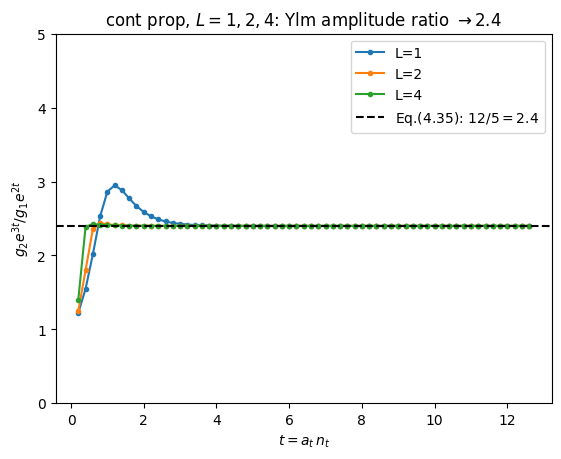

In [18]:
# Ylm ratio g2 e^{3t} / g1 e^{2t} -> 12/5 = 2.4 : convergence with L
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft

plt.figure()
for L in [1, 2, 4]:
    cd = "corr_deter_local_cont_L%d" % L
    try:
        g1 = load_Vpp(cd, "ylm/l1").real
        g2 = load_Vpp(cd, "ylm/l2").real
    except (OSError, KeyError):
        print("missing:", cd); continue
    plt.plot(t, (g2[dt]*np.exp(3.0*t))/(g1[dt]*np.exp(2.0*t)), '.-', label="L=%d" % L)
plt.axhline(12.0/5.0, color='k', ls='dashed', label=r"Eq.(4.35): $12/5 = 2.4$")
plt.xlabel(r"$t = a_t\, n_t$"); plt.ylabel(r"$g_2 e^{3t}/g_1 e^{2t}$"); plt.ylim(0, 5)
plt.title("cont prop, $L=1,2,4$: Ylm amplitude ratio $\\to 2.4$")
plt.legend()
plt.savefig("cft_ylm_ratio_cont_L124.pdf", bbox_inches="tight")

## $\ell=0$ mode $\to 0$ with $L$  (continuum prop)

The $\ell=0$ projection of $G_t$ vanishes in the continuum (charge-conservation Ward identity:
$\ell=0$ is the total charge $Q$, and $\langle Q(t_0)Q(t)\rangle=0$). On the icosahedral lattice it
is a small **angular-aliasing artifact**: the 12/42/162-point rule is a spherical **5-design** at
every $L$, so the first harmonic that leaks into $\ell=0$ is $\ell=6$. Hence $|G^t_{00}|\sim E_6^2$
(crashes $\sim10^3$ from $L=1\to2$, then $\sim1/L^4$) with an $L$-**fixed** decay rate $e^{-7t}$
($\ell=6\to6+1$). Full mechanism + numbers in `jj_ell0_Ldecay_summary_claude.md`.

The data **does** show this (it was masked before by an overlay that plotted the $L=1$ $g_0$ for all
$L$): $|g_0|$ at $dt=5$ is $2.6\times10^{-4}\to2.8\times10^{-6}\to8.1\times10^{-8}$ for $L=1,2,4$.
The continuum results are cached in `corr_deter_local_cont_L{1,2,4}/corr.0.h5` (the `--out-tag cont`
dirs, distinct from the lattice `corr_deter_local_L*`), so no recomputation is needed.

|g0| at dt=5: {1: 0.000260339265182758, 2: 2.7916015857618945e-06, 4: 8.132936133012234e-08}
|g0(L)|/|g0(1)| at dt=5: {1: 1.0, 2: 0.010722937178923786, 4: 0.00031239759885251723}


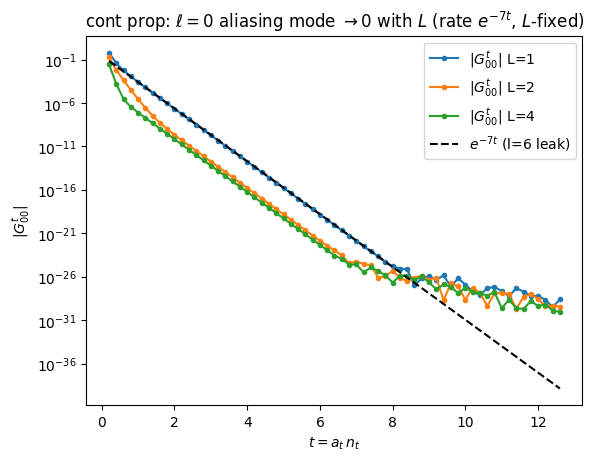

In [19]:
# ell=0 mode -> 0 as L grows.  It is an l=6 angular-aliasing artifact (5-design leak): magnitude
# ~ E_6^2 ~ 1/L^4 (crashes ~10^3 from L=1 to L=2), with an L-FIXED decay rate e^{-7t} (l=6 -> 6+1).
# See jj_ell0_Ldecay_summary_claude.md.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft

g0L = {}
plt.figure()
for L in [1, 2, 4]:
    cd = "corr_deter_local_cont_L%d" % L
    try:
        g0L[L] = load_Vpp(cd, "ylm/l0").real
    except (OSError, KeyError):
        print("missing:", cd); continue
    plt.plot(t, np.abs(g0L[L][dt]), '.-', label=r"$|G^t_{00}|$ L=%d" % L)
if 1 in g0L:
    A0 = np.abs(g0L[1][5]) / np.exp(-7.0*t[4])     # e^{-7t} slope anchored to L=1
    plt.plot(t, A0*np.exp(-7.0*t), 'k--', label=r"$e^{-7t}$ (l=6 leak)")
plt.yscale("log"); plt.xlabel(r"$t = a_t\, n_t$"); plt.ylabel(r"$|G^t_{00}|$")
plt.title(r"cont prop: $\ell=0$ aliasing mode $\to 0$ with $L$ (rate $e^{-7t}$, $L$-fixed)")
plt.legend()
plt.savefig("cft_ylm_l0_Ldecay_cont.pdf", bbox_inches="tight")

# magnitude crash with L at a fixed separation (expect ~ E_6^2 ratios; see summary table)
ref0 = 5
print("|g0| at dt=%d:" % ref0, {L: float(np.abs(g0L[L][ref0])) for L in sorted(g0L)})
if 1 in g0L:
    print("|g0(L)|/|g0(1)| at dt=%d:" % ref0,
          {L: float(np.abs(g0L[L][ref0] / g0L[1][ref0])) for L in sorted(g0L)})